# StudyMate v2 — 점수 기반 분기 + 웹검색 보강

데모 데이 Day 2. 0506의 StudyMate(개념→카드→퀴즈)에 두 가지 추가:

1. **사용자 답안 + 점수 기반 Conditional Edge** — 75% 임계값으로 통과/보강 분기
2. **DuckDuckGo 웹검색 Tool** — 틀린 개념마다 추가 자료 검색해 설명 보강

## 그래프

```
START
  │
  ▼
analyze_topic         ── 핵심 개념 5개 (LLM)
  │ Send dispatch_cards
  ▼
make_flashcard × 5    ── 병렬 카드 생성
  │
  ▼
make_quiz             ── 객관식 4문제
  │
  ▼
take_quiz             ── interrupt()로 사용자 답안 받기
  │
  ▼
grade_quiz            ── 점수 계산 + 틀린 개념 추출
  │ Conditional Edge (점수 기반)
  ├─ ≥ 75% ─▶ summarize_well_done ─▶ END
  └─ < 75% ─▶ search_concepts (Send) ─▶ review_explain ─▶ END
                  ↑ DuckDuckGo Tool 호출
```

## 구현 요구사항 매핑

| 요구사항 | 위치 |
| --- | --- |
| 노드 3개+ | 8개 (analyze_topic, make_flashcard, make_quiz, take_quiz, grade_quiz, summarize_well_done, search_concepts, review_explain) |
| Conditional Edge | `grade_quiz` → 점수에 따라 분기 |
| Tool 연동 | DuckDuckGoSearchRun (search_concepts에서 호출) |
| Send 병렬 (bonus) | dispatch_cards (5장), dispatch_searches (틀린 개념별) |
| 메모리 (bonus) | InMemorySaver checkpointer (interrupt resume용) |

## Step 1 — 환경 + 임포트

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import START, END, StateGraph
from langgraph.types import Send, interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain_community.tools import DuckDuckGoSearchRun
from typing import TypedDict
from typing_extensions import Annotated
import operator
import json

llm = init_chat_model("openai:gpt-4o-mini")
search_tool = DuckDuckGoSearchRun()

/Users/sio/Dropbox/개발공부/ai_agent_club/0510_assignment/.venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## Step 2 — State

0506 대비 추가 필드:
- `user_answers` — 사용자가 입력한 답안 인덱스 리스트
- `score` — 정답 비율 (0.0~1.0)
- `wrong_concepts` — 틀린 문제와 연관된 개념
- `search_results` — DuckDuckGo로 가져온 자료 (Send fan-in이라 누적)
- `final_message` — 최종 출력

In [3]:
class State(TypedDict):
    topic: str
    concepts: list[str]
    flashcards: Annotated[list[dict], operator.add]
    quiz: list[dict]
    user_answers: list[int]
    score: float
    wrong_concepts: list[str]
    search_results: Annotated[list[dict], operator.add]
    final_message: str

In [4]:
def parse_json(text: str):
    """gpt-4o-mini가 ```json 코드블록으로 답할 때 벗겨내는 유틸."""
    text = text.strip()
    if text.startswith("```"):
        text = text.strip("`").strip()
        if text.startswith("json"):
            text = text[4:].strip()
    return json.loads(text)

## Step 3 — 기존 노드 (0506에서 그대로)

In [7]:
def analyze_topic(state: State):
    prompt =  f"""
    학습 주제: {state["topic"]}

    위 주제를 처음 공부하는 학습자가 반드시 알아야 할 핵심 개념을 정확히 5개 뽑아줘.
    각 항목은 짧은 한국어 명사구.
    출력은 JSON 배열만, 예: ["개념1", "개념2", ...]
    """
    response = llm.invoke(prompt)
    concepts = parse_json(response.content)
    return {"concepts": concepts}


def dispatch_cards(state: State):
    return [
        Send("make_flashcard", {"concept": c, "topic": state["topic"]})
        for c in state["concepts"]
    ]


def make_flashcard(args):
    prompt = f"""
    주제: {args["topic"]}
    개념: {args["concept"]}

    위 개념을 학습용 플래시카드로 만들어줘. 형식은 JSON:
    {{"concept": "{args['concept']}", "question": "...", "answer": "..."}}
    answer는 2~3문장 한국어로 간결하게.
    """
    response = llm.invoke(prompt)
    card = parse_json(response.content)
    return {"flashcards": [card]}


def make_quiz(state: State):
    concepts = "\n".join(f"- {c}" for c in state["concepts"])
    prompt = f"""
    주제: {state["topic"]}
    핵심 개념:
    {concepts}

    위 개념들의 이해도를 점검할 객관식 4문제를 만들어줘.
    각 문제는 4지선다, 정답 인덱스(0~3) 포함.
    각 문제에 어떤 개념을 묻는지 "concept" 필드도 추가해.
    출력은 JSON 배열:
    [{{"q": "...", "options": ["a","b","c","d"], "answer_index": 0, "concept": "..."}}, ...]
    """
    response = llm.invoke(prompt)
    quiz = parse_json(response.content)
    return {"quiz": quiz}

## Step 4 — NEW: take_quiz (interrupt로 답안 받기)

강의 #15.5에서 본 `interrupt()` 패턴. 사용자에게 퀴즈 보여주고 답안 4개를 한 번에 받는다.
콘솔에 입력받는 형태(예: `"0,2,1,3"`)로 단순화.

In [8]:
def take_quiz(state: State):
    quiz_display = []
    for i, q in enumerate(state["quiz"], 1):
        opts = "\n".join(f"   {j}) {opt}" for j, opt in enumerate(q["options"]))
        quiz_display.append(f"[{i}] {q['q']}\n{opts}")
    quiz_text = "\n\n".join(quiz_display)

    user_input = interrupt(
        {
            "prompt": (
                f"📝 퀴즈 ({len(state['quiz'])}문제). 정답 인덱스(0~3)를 콤마로 구분해 입력하세요.\n"
                f"예: 0,2,1,3\n\n{quiz_text}"
            ),
        }
    )
    answers = [int(x.strip()) for x in str(user_input).split(",")]
    return {"user_answers": answers}

## Step 5 — NEW: grade_quiz

정답 비율 계산 + 틀린 문제의 `concept` 모아서 다음 단계 분기 데이터 준비.

In [9]:
def grade_quiz(state: State):
    correct = 0
    wrong_concepts = []
    for q, ans in zip(state["quiz"], state["user_answers"]):
        if ans == q["answer_index"]:
            correct += 1
        else:
            wrong_concepts.append(q.get("concept", ""))
    score = correct / len(state["quiz"]) if state["quiz"] else 0.0
    return {"score": score, "wrong_concepts": wrong_concepts}

## Step 6 — NEW: Conditional Edge

사용자 점수에 따라 두 분기 중 하나를 선택. **이게 과제 핵심 요구사항**.

- ≥ 75% → 잘했어요 노드로
- < 75% → 웹검색 후 보강 노드로

In [10]:
PASS_THRESHOLD = 0.75


def route_by_score(state: State):
    if state["score"] >= PASS_THRESHOLD:
        return "summarize_well_done"
    return "dispatch_searches"

## Step 7 — Pass branch: summarize_well_done

In [11]:
def summarize_well_done(state: State):
    correct = int(state["score"] * len(state["quiz"]))
    msg = (
        f"🎉 잘했어요! 점수: {correct}/{len(state['quiz'])} ({state['score']*100:.0f}%)\n"
        f"주제 '{state['topic']}'의 핵심을 잘 파악하고 있습니다. 다음 주제로 넘어가도 좋아요."
    )
    return {"final_message": msg}

## Step 8 — Fail branch: 웹검색 (Tool 호출, Send 병렬)

틀린 개념별로 DuckDuckGo 검색을 병렬 실행. `search_concepts`는 1개 개념을 받아 검색 결과 1건을 반환.

In [12]:
def dispatch_searches(state: State):
    return [
        Send("search_concepts", {"concept": c, "topic": state["topic"]})
        for c in state["wrong_concepts"]
    ]


def search_concepts(args):
    query = f"{args['topic']} {args['concept']} 개념 설명"
    try:
        result = search_tool.invoke(query)
    except Exception as e:
        result = f"(검색 실패: {e})"
    return {
        "search_results": [
            {"concept": args["concept"], "snippet": result[:800]}
        ]
    }

## Step 9 — review_explain

검색 결과를 LLM에 넘겨 학습자 친화적 설명으로 재가공.
fan-in 자리(여러 검색 결과 → 단일 메시지).

In [13]:
def review_explain(state: State):
    correct = int(state["score"] * len(state["quiz"]))
    research_blocks = "\n\n".join(
        f"### {r['concept']}\n{r['snippet']}" for r in state["search_results"]
    )
    prompt = f"""
    학습자가 주제 '{state["topic"]}'의 퀴즈에서 {correct}/{len(state["quiz"])}점을 맞았습니다.
    틀린 개념: {', '.join(state['wrong_concepts'])}

    아래는 그 개념들에 대한 웹검색 결과입니다. 학습자에게 친절한 한국어 설명으로 재구성해주세요.
    각 개념마다 2~3문장으로 핵심을 짚고, 다음에 어떻게 공부하면 좋을지 한 줄 가이드를 덧붙여주세요.

    웹검색 결과:
    {research_blocks}

    출력 형식:
    📚 보강 학습

    [개념1]
    설명...
    👉 다음 단계: ...

    [개념2]
    ...
    """
    response = llm.invoke(prompt)
    msg = (
        f"📊 점수: {correct}/{len(state['quiz'])} ({state['score']*100:.0f}%)\n\n"
        f"{response.content}"
    )
    return {"final_message": msg}

## Step 10 — 그래프 연결

In [14]:
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_topic", analyze_topic)
graph_builder.add_node("make_flashcard", make_flashcard)
graph_builder.add_node("make_quiz", make_quiz)
graph_builder.add_node("take_quiz", take_quiz)
graph_builder.add_node("grade_quiz", grade_quiz)
graph_builder.add_node("summarize_well_done", summarize_well_done)
graph_builder.add_node("search_concepts", search_concepts)
graph_builder.add_node("review_explain", review_explain)

graph_builder.add_edge(START, "analyze_topic")
graph_builder.add_conditional_edges(
    "analyze_topic", dispatch_cards, ["make_flashcard"]
)
graph_builder.add_edge("make_flashcard", "make_quiz")
graph_builder.add_edge("make_quiz", "take_quiz")
graph_builder.add_edge("take_quiz", "grade_quiz")

# ⭐ 핵심 Conditional Edge — 사용자 점수에 따라 분기
graph_builder.add_conditional_edges(
    "grade_quiz",
    route_by_score,
    ["summarize_well_done", "dispatch_searches"],
)

# Send를 위해서는 dispatch_searches도 노드처럼 등록 (no-op으로)
def dispatch_searches_node(state: State):
    return {}


graph_builder.add_node("dispatch_searches", dispatch_searches_node)
graph_builder.add_conditional_edges(
    "dispatch_searches", dispatch_searches, ["search_concepts"]
)
graph_builder.add_edge("search_concepts", "review_explain")

graph_builder.add_edge("summarize_well_done", END)
graph_builder.add_edge("review_explain", END)

# bonus: 메모리 — interrupt resume용 checkpointer
checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer, name="study_mate_v2")

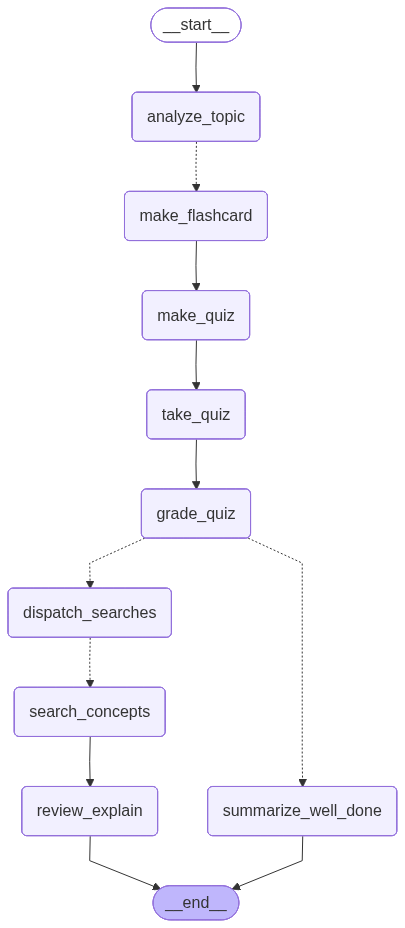

In [15]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## Step 11 — 실행

checkpointer가 있어서 thread_id 필요. 첫 invoke로 take_quiz까지 가서 멈춤(interrupt) → 답안을 Command로 resume → 끝까지 진행.

In [18]:
config = {"configurable": {"thread_id": "demo-1"}}

# 1차: take_quiz의 interrupt에서 멈춤
stream = graph.invoke({"topic": "FastAPI 의존성 주입(Dependency Injection)"}, config=config)

# interrupt 데이터 확인
interrupted = stream.get("__interrupt__")
if interrupted:
    print(interrupted[0].value["prompt"])

📝 퀴즈 (4문제). 정답 인덱스(0~3)를 콤마로 구분해 입력하세요.
예: 0,2,1,3

[1] FastAPI에서 의존성 주입이란 무엇을 의미하나요?
   0) 서버에 데이터를 저장하는 기능
   1) 함수나 경로가 다른 함수나 경로에 의존적인 관계를 정의하는 것
   2) HTTP 요청을 처리하는 방식
   3) API 문서를 자동으로 생성하는 기능

[2] FastAPI의 선언형 경로에서 주로 사용되는 방법은 무엇인가요?
   0) 클래스를 직접 호출하는 방식
   1) Python의 타입 힌트를 사용하는 방식
   2) URL을 직접 매핑하는 방식
   3) JSON 객체를 반환하는 방식

[3] FastAPI에서 주입 가능한 클래스는 무엇을 나타내나요?
   0) HTTP 메소드
   1) 입력 데이터의 형식
   2) 의존성으로 주입될 수 있는 객체
   3) 라우터의 URL 경로

[4] FastAPI에서 비동기 함수를 지원하는 이유는 무엇인가요?
   0) 실시간 데이터 처리 속도를 높이기 위해
   1) 서버 자원을 절약하기 위해
   2) HTTP 요청을 더 빠르게 처리하기 위해
   3) 모든 함수에서 비동기를 사용해야 하기 때문에


In [21]:
# 2차: 사용자 답안 입력 (콘솔)
user_answers = input("답안 입력 (예: 0,2,1,3): ")
result = graph.invoke(Command(resume=user_answers), config=config)

print("\n" + "=" * 60)
print(result["final_message"])
print("=" * 60)

답안 입력 (예: 0,2,1,3):  0,0,0,0



📊 점수: 0/4 (0%)

📚 보강 학습

[의존성 주입]
의존성 주입(Dependency Injection, DI)은 객체가 직접 필요로 하는 의존성을 생성하지 않고, 외부에서 주입받아 사용하는 디자인 패턴입니다. FastAPI에서는 `Depends()`를 통해 이 의존성 주입을 구현하여 코드의 재사용성을 높이고 테스트를 간편하게 합니다. 이 기능은 특히 빠른 개발과 유지 보수를 가능하게 합니다.  
👉 다음 단계: FastAPI의 공식 문서를 통해 `Depends` 기능을 활용한 실습 예제를 진행해 보세요.

[선언형 경로]
선언형 경로는 URL 경로를 선언적으로 정의하는 방식으로, FastAPI의 강력한 기능 중 하나입니다. 이를 통해 특정 경로가 어떤 의존성을 요구하는지를 명확하게 기술할 수 있습니다. 이 방법은 코드의 모듈화와 가독성을 높이며, 오류를 줄이는 데도 기여합니다.  
👉 다음 단계: FastAPI의 경로 선언에 대한 예제를 찾아 따라 해보며 실전에서 활용해 보세요.

[주입 가능한 클래스]
주입 가능한 클래스는 특정 작업을 수행하기 위해 외부에서 제공되는 의존성을 이용할 수 있게 해주는 클래스를 의미합니다. FastAPI에서는 이러한 클래스를 생성하여, 의존성 주입을 통해 다른 엔드포인트에 쉽게 재사용할 수 있습니다. 이를 통해 코드의 결합도를 낮추고 유지 보수가 용이해집니다.  
👉 다음 단계: 주입 가능한 클래스를 작성하고 FastAPI 엔드포인트와 연결하여 테스트해 보세요.

[비동기 함수 지원]
FastAPI에서는 비동기 함수에 대한 의존성 주입을 지원하여, API 요청에 대한 처리를 동시에 여러 개 진행할 수 있도록 해줍니다. `Depends()`를 사용하여 비동기 함수도 쉽게 주입할 수 있으며, 이는 성능을 크게 향상시킬 수 있습니다.  
👉 다음 단계: 비동기 함수와 의존성 주입을 활용한 FastAPI 프로젝트를 생성해 보세요.


## Step 12 — 중간 결과 확인 (디버깅용)

In [22]:
print("=== 핵심 개념 ===")
for c in result["concepts"]:
    print(" -", c)

print("\n=== 플래시카드 ===")
for i, card in enumerate(result["flashcards"], 1):
    print(f"[{i}] ({card.get('concept', '')}) Q. {card['question']}")
    print(f"    A. {card['answer']}\n")

print("=== 퀴즈 + 사용자 답안 ===")
for i, (q, ans) in enumerate(zip(result["quiz"], result["user_answers"]), 1):
    correct = "✓" if ans == q["answer_index"] else "✗"
    print(f"{correct} [{i}] {q['q']}")
    print(f"    내 답: {ans}, 정답: {q['answer_index']} ({q.get('concept','')})")

print(f"\n=== 점수 ===")
print(f"{result['score']*100:.0f}%")
if result.get("wrong_concepts"):
    print(f"틀린 개념: {result['wrong_concepts']}")
if result.get("search_results"):
    print(f"\n=== 웹검색 결과 ({len(result['search_results'])}건) ===")
    for r in result["search_results"]:
        print(f"\n[{r['concept']}]")
        print(r["snippet"][:200], "...")

=== 핵심 개념 ===
 - 의존성 주입
 - 선언형 경로
 - 주입 가능한 클래스
 - 요청 주기
 - 비동기 함수 지원

=== 플래시카드 ===
[1] (의존성 주입) Q. FastAPI에서 의존성 주입이란 무엇인가?
    A. 의존성 주입은 객체나 클래스를 생성할 때 필요한 의존성을 외부에서 주입하는 방법입니다. FastAPI에서는 함수의 인자로 의존성을 주입하여 코드의 재사용성과 테스트 용이성을 높입니다.

[2] (FastAPI) Q. FastAPI에서 의존성 주입이란 무엇인가?
    A. 의존성 주입은 FastAPI에서 라우트 핸들러가 필요한 리소스를 자동으로 주입받도록 하는 방법입니다. 이를 통해 코드의 재사용성을 높이고, 의존성을 관리하기 용이하게 하여 테스트와 유지보수가 쉬워집니다.

[3] (경량화) Q. FastAPI의 의존성 주입에서 경량화란 무엇인가?
    A. 경량화는 FastAPI의 의존성 주입을 통해 필요한 의존성을 효율적으로 관리하는 과정을 의미합니다. 이를 통해 애플리케이션의 성능을 높이고, 코드의 가독성을 개선할 수 있습니다.

[4] (비동기 처리) Q. FastAPI에서 비동기 처리란 무엇인가?
    A. 비동기 처리는 동시에 여러 작업을 수행할 수 있는 기능으로, FastAPI는 이를 통해 I/O 작업의 효율성을 높입니다. 이를 통해 요청이 대기하는 동안 다른 작업을 할 수 있어 성능이 향상됩니다.

[5] (타입 힌트) Q. FastAPI에서 타입 힌트는 어떤 역할을 하나요?
    A. 타입 힌트는 함수의 매개변수와 반환 값의 데이터 타입을 명시하여 코드의 가독성과 안정성을 높입니다. FastAPI는 이 정보를 활용하여 자동으로 API 문서를 생성하고, 클라이언트 요청의 유효성을 검사합니다.

[6] (의존성 주입) Q. FastAPI에서 의존성 주입이란 무엇인가?
    A. 의존성 주입은 객체나 함수가 필요한 의존성을 외부에서 주입받는 디자인 패턴입니다. FastAPI에서는 이를 통해 API 경로 처리 